In [1]:
import pandas as pd
df = pd.read_csv("../data/raw/Bank Customer Churn Prediction.csv")

1. Business Understanding
Objetivo : Predecir que clientes tienen probabilidad de abandonar el banco y remitirlos a campañas de retención

2. Data Context
- cuantas filas y columnas?
- cual es el target?
- esta balanceado?

In [2]:
# 10 000 registros con 12 columnas
df.shape

(10000, 12)

In [3]:
# Vemos que el target es la columna "churn" y que no hay datos nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [4]:
# Ver un sample de la data
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# Revisar distribucion de la variable objetivo - validamos si es balanceada o no
print(df["churn"].value_counts())
print(f"Churn distribucion: {df['churn'].mean()*100:.2f}%")

churn
0    7963
1    2037
Name: count, dtype: int64
Churn distribucion: 20.37%


### Observaciones iniciales
- La clase presenta imbalance : churn representa el 20% aprox de toda la data
    - Para casos de churn es una tasa normal, se necesitara usar sampling stratificado para mantener el mismo ratio de distribucion

- La columna "customer_id" es irrelevante para nuestro objetivo por ser un identificador único

- El dataset presenta variables numericas y categóricas.

In [6]:
df.drop("customer_id", axis=1, inplace=True)

## Graficos para explorar distribucion entre variables


Resumen estadístico:
       credit_score           age        tenure        balance  \
count  10000.000000  10000.000000  10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288   
std       96.653299     10.487806      2.892174   62397.405202   
min      350.000000     18.000000      0.000000       0.000000   
25%      584.000000     32.000000      3.000000       0.000000   
50%      652.000000     37.000000      5.000000   97198.540000   
75%      718.000000     44.000000      7.000000  127644.240000   
max      850.000000     92.000000     10.000000  250898.090000   

       products_number  credit_card  active_member  estimated_salary  \
count     10000.000000  10000.00000   10000.000000      10000.000000   
mean          1.530200      0.70550       0.515100     100090.239881   
std           0.581654      0.45584       0.499797      57510.492818   
min           1.000000      0.00000       0.000000         11.580000   
25%           1.000000 

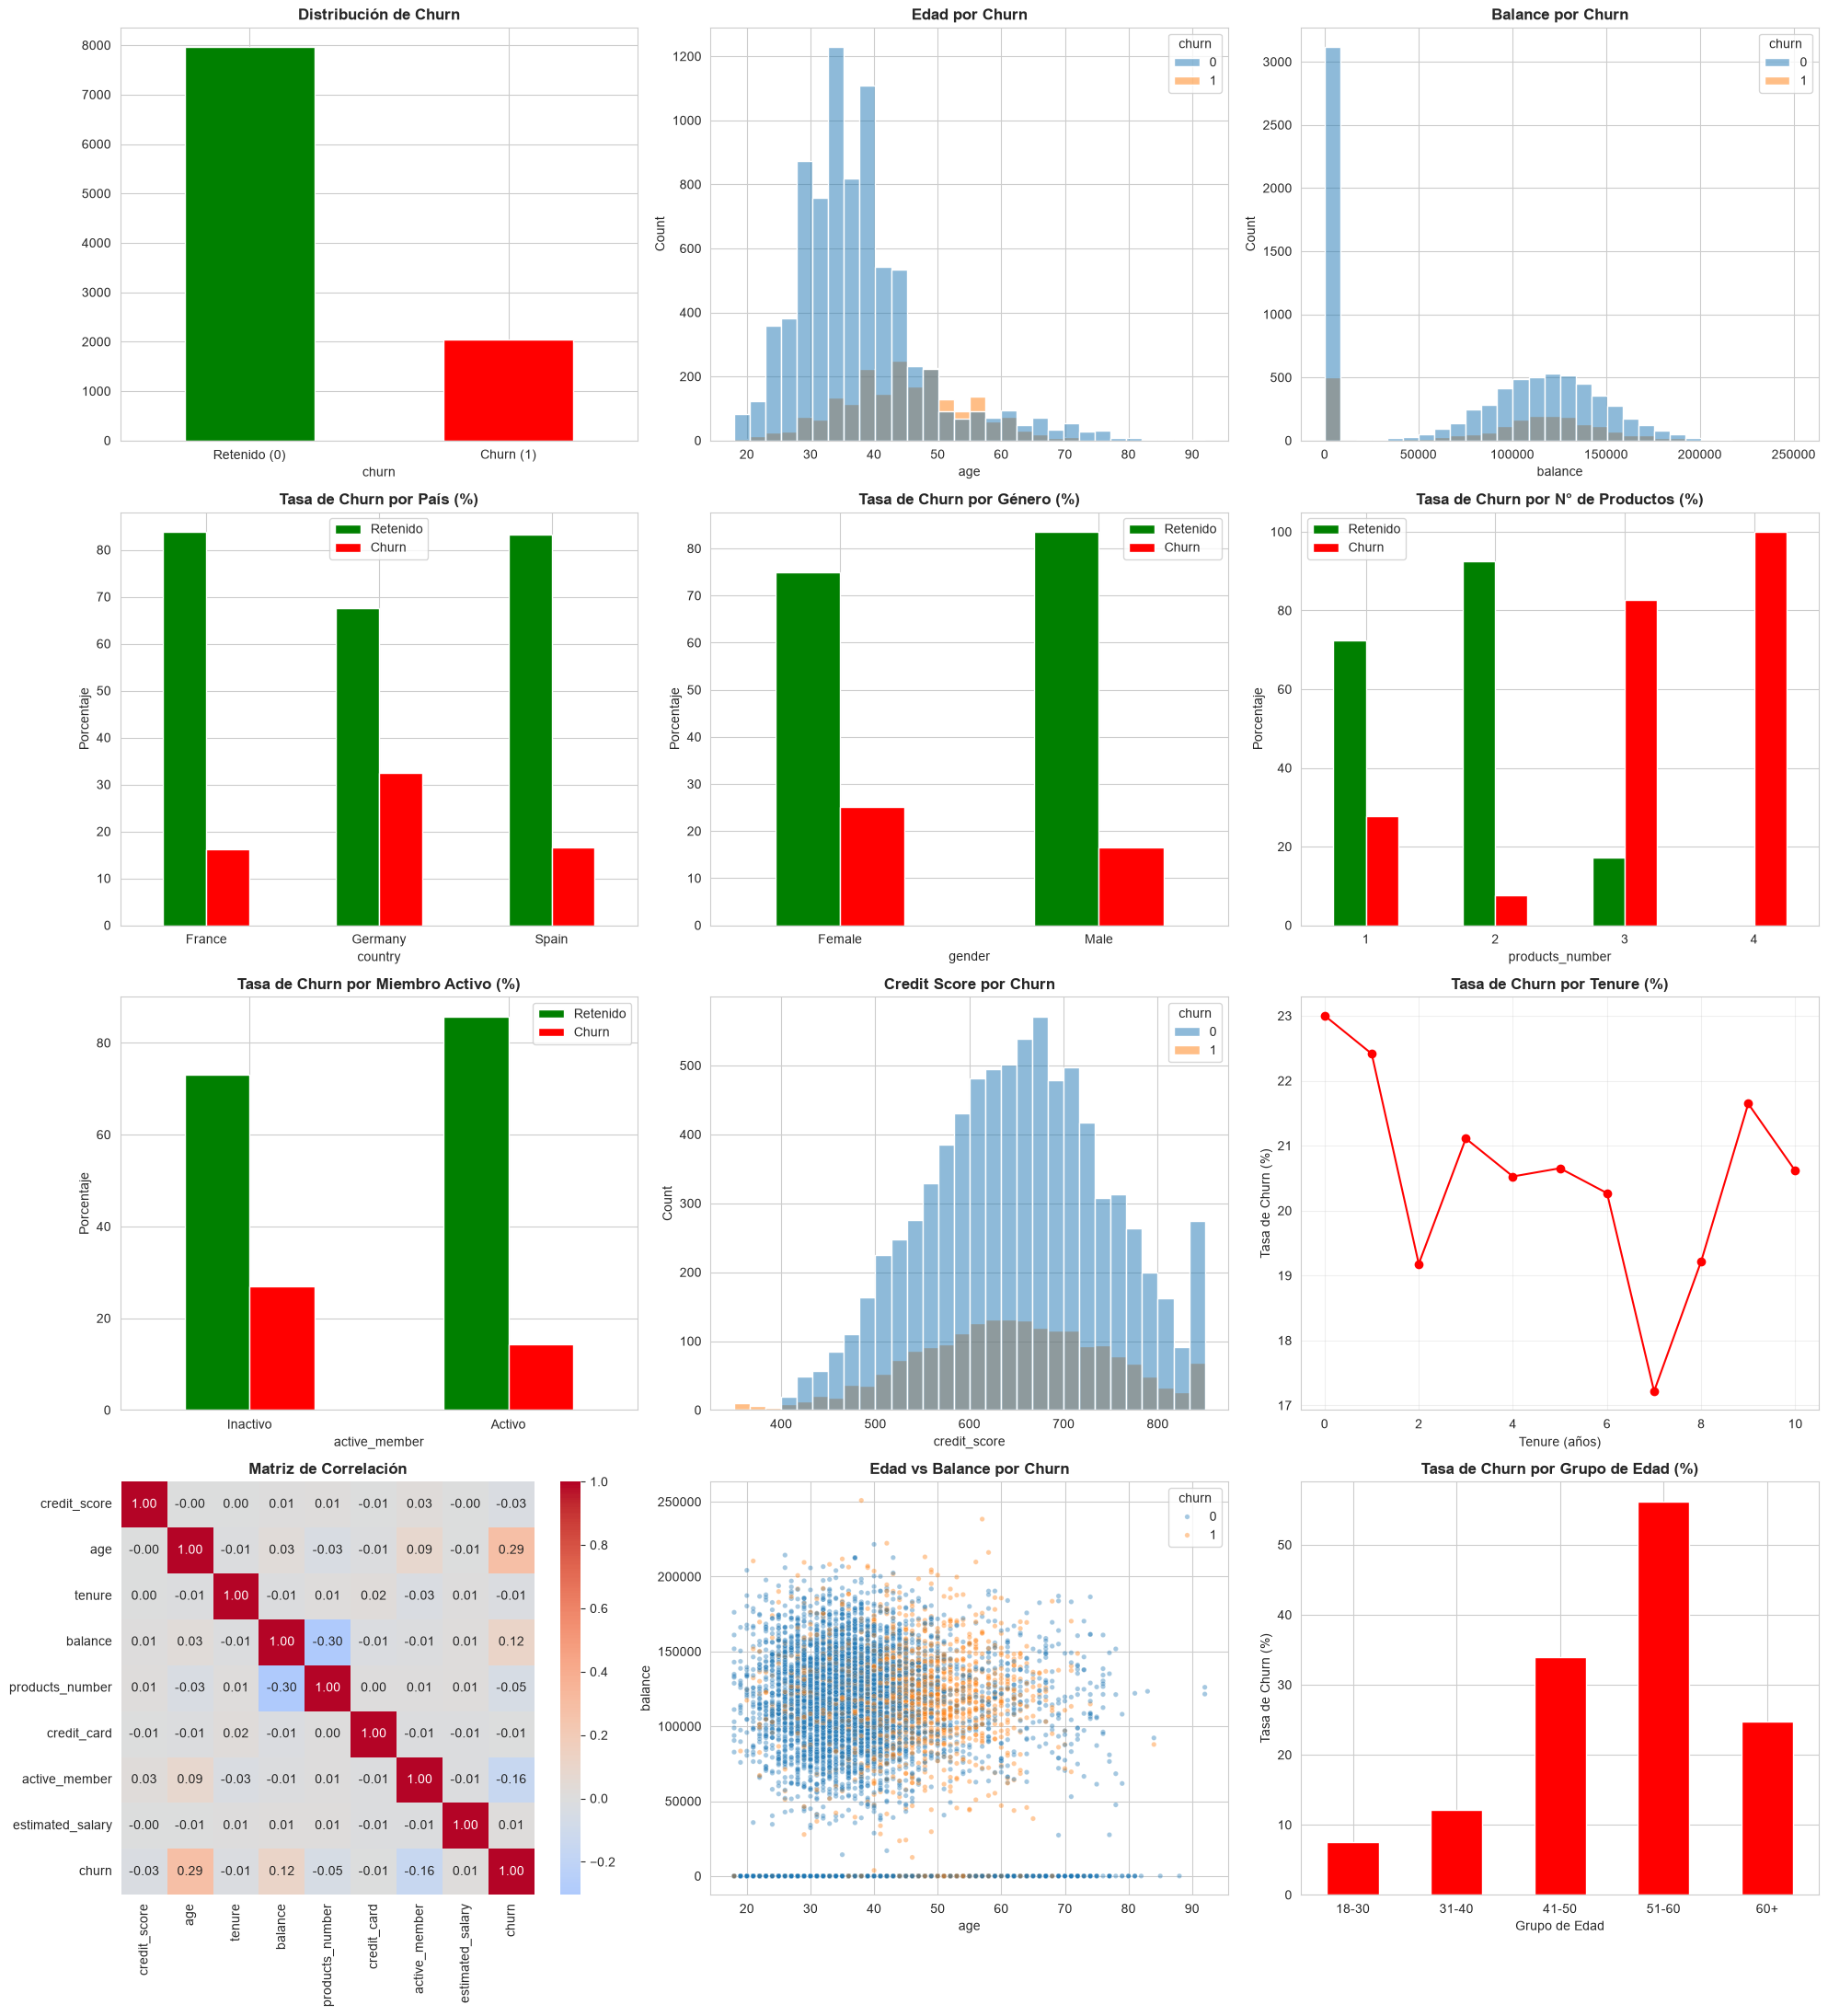

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
# Estadísticas básicas
print("\nResumen estadístico:")
print(df.describe())
 
sns.set_style("whitegrid")
labels = {0: 'Retenido', 1: 'Churn'}
 
fig, axes = plt.subplots(4, 3, figsize=(20, 22))
 
# 1. Distribución de Churn
df['churn'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0, 0], color=['green', 'red'])
axes[0, 0].set_title('Distribución de Churn', fontweight='bold')
axes[0, 0].set_xticklabels(['Retenido (0)', 'Churn (1)'], rotation=0)
 
# 2. Edad por Churn
sns.histplot(data=df, x='age', hue='churn', bins=30, ax=axes[0, 1])
axes[0, 1].set_title('Edad por Churn', fontweight='bold')
 
# 3. Balance por Churn
sns.histplot(data=df, x='balance', hue='churn', bins=30, ax=axes[0, 2])
axes[0, 2].set_title('Balance por Churn', fontweight='bold')
 
# 4. Churn por País (tasa %)
country_churn = pd.crosstab(df['country'], df['churn'], normalize='index') * 100
country_churn.plot(kind='bar', ax=axes[1, 0], color=['green', 'red'])
axes[1, 0].set_title('Tasa de Churn por País (%)', fontweight='bold')
axes[1, 0].set_ylabel('Porcentaje')
axes[1, 0].legend(labels.values())
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
 
# 5. Churn por Género (tasa %)
gender_churn = pd.crosstab(df['gender'], df['churn'], normalize='index') * 100
gender_churn.plot(kind='bar', ax=axes[1, 1], color=['green', 'red'])
axes[1, 1].set_title('Tasa de Churn por Género (%)', fontweight='bold')
axes[1, 1].set_ylabel('Porcentaje')
axes[1, 1].legend(labels.values())
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
 
# 6. Churn por Número de Productos (tasa %)
products_churn = pd.crosstab(df['products_number'], df['churn'], normalize='index') * 100
products_churn.plot(kind='bar', ax=axes[1, 2], color=['green', 'red'])
axes[1, 2].set_title('Tasa de Churn por N° de Productos (%)', fontweight='bold')
axes[1, 2].set_ylabel('Porcentaje')
axes[1, 2].legend(labels.values())
axes[1, 2].set_xticklabels(axes[1, 2].get_xticklabels(), rotation=0)
 
# 7. Churn por Miembro Activo (tasa %)
active_churn = pd.crosstab(df['active_member'], df['churn'], normalize='index') * 100
active_churn.plot(kind='bar', ax=axes[2, 0], color=['green', 'red'])
axes[2, 0].set_title('Tasa de Churn por Miembro Activo (%)', fontweight='bold')
axes[2, 0].set_ylabel('Porcentaje')
axes[2, 0].set_xticklabels(['Inactivo', 'Activo'], rotation=0)
axes[2, 0].legend(labels.values())
 
# 8. Credit Score por Churn
sns.histplot(data=df, x='credit_score', hue='churn', bins=30, ax=axes[2, 1])
axes[2, 1].set_title('Credit Score por Churn', fontweight='bold')
 
# 9. Churn por Tenure (tasa %)
tenure_churn = pd.crosstab(df['tenure'], df['churn'], normalize='index') * 100
tenure_churn[1].plot(kind='line', marker='o', ax=axes[2, 2], color='red')
axes[2, 2].set_title('Tasa de Churn por Tenure (%)', fontweight='bold')
axes[2, 2].set_xlabel('Tenure (años)')
axes[2, 2].set_ylabel('Tasa de Churn (%)')
axes[2, 2].grid(True, alpha=0.3)
 
# 10. Matriz de correlación
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[3, 0])
axes[3, 0].set_title('Matriz de Correlación', fontweight='bold')
 
# 11. Edad vs Balance
sns.scatterplot(data=df, x='age', y='balance', hue='churn',
                 alpha=0.4, s=15, ax=axes[3, 1])
axes[3, 1].set_title('Edad vs Balance por Churn', fontweight='bold')
 
# 12. Tasa de Churn por Grupo de Edad
df['age_group'] = pd.cut(df['age'], bins=[18, 30, 40, 50, 60, 100],
                          labels=['18-30', '31-40', '41-50', '51-60', '60+'])
age_group_churn = pd.crosstab(df['age_group'], df['churn'], normalize='index') * 100
age_group_churn[1].plot(kind='bar', ax=axes[3, 2], color='red')
axes[3, 2].set_title('Tasa de Churn por Grupo de Edad (%)', fontweight='bold')
axes[3, 2].set_xlabel('Grupo de Edad')
axes[3, 2].set_ylabel('Tasa de Churn (%)')
axes[3, 2].set_xticklabels(axes[3, 2].get_xticklabels(), rotation=0)
 
plt.tight_layout()
plt.savefig('../images/eda_simple.png', dpi=200, bbox_inches='tight')
print("\nVisualizaciones EDA generadas")
plt.show()
